In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & SYNTHETIC DATASET GENERATION
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)

n_samples = 1500

# Date column
date_range = pd.date_range(
    start="2024-01-01",
    end="2024-12-31",
    periods=n_samples
)

# Categorical columns
regions = np.random.choice(
    ["North America", "Europe", "Asia-Pacific", "Latin America"],
    size=n_samples,
    p=[0.40, 0.30, 0.20, 0.10]
)

customer_tier = np.random.choice(
    ["Standard", "Silver", "Gold", "Platinum"],
    size=n_samples,
    p=[0.50, 0.25, 0.15, 0.10]
)

product_category = np.random.choice(
    ["Hardware", "SaaS Subscriptions", "Consulting", "Support Add-ons"],
    size=n_samples,
    p=[0.35, 0.30, 0.20, 0.15]
)

# Numerical columns
units = np.random.poisson(lam=4, size=n_samples).clip(1, 20)

base_prices = {
    "Hardware": 450.0,
    "SaaS Subscriptions": 120.0,
    "Consulting": 250.0,
    "Support Add-ons": 75.0
}

unit_price = np.array([
    base_prices[cat] for cat in product_category
]) * np.random.uniform(0.85, 1.15, size=n_samples)

discount_pct = np.random.beta(
    a=2,
    b=8,
    size=n_samples
) * 0.40

gross_revenue = units * unit_price
net_revenue = gross_revenue * (1 - discount_pct)

cost_price = gross_revenue * np.random.uniform(
    0.40,
    0.65,
    size=n_samples
)

profit_margin = (
    (net_revenue - cost_price) / net_revenue
) * 100

csat_score = (
    np.random.normal(
        loc=4.2,
        scale=0.6,
        size=n_samples
    ) - (discount_pct * 1.5)
).clip(1.0, 5.0)

# Create DataFrame
df = pd.DataFrame({
    "Date": date_range,
    "Region": regions,
    "Customer_Tier": customer_tier,
    "Category": product_category,
    "Units_Sold": units,
    "Unit_Price": np.round(unit_price, 2),
    "Gross_Revenue": np.round(gross_revenue, 2),
    "Discount_Pct": np.round(discount_pct, 4),
    "Net_Revenue": np.round(net_revenue, 2),
    "Profit_Margin_Pct": np.round(profit_margin, 2),
    "CSAT_Score": np.round(csat_score, 2)
})

# Add month columns
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()
df["Month_Name"] = df["Date"].dt.strftime("%b")

# Save dataset
df.to_csv("day4_retail_bi.csv", index=False)

print("Dataset generated successfully!")
print(f"Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")

display(df.head())

Dataset generated successfully!
Dimensions: 1500 rows x 13 columns


,Date,Region,Customer_Tier,Category,Units_Sold,Unit_Price,Gross_Revenue,Discount_Pct,Net_Revenue,Profit_Margin_Pct,CSAT_Score,Month,Month_Name
0,2024-01-01 00:00:00.000000000,North America,Silver,Consulting,3,224.70,674.09,0.0812,619.32,48.43,4.20,2024-01-01,Jan
1,2024-01-01 05:50:38.025350233,Latin America,Standard,Consulting,3,241.60,724.81,0.0821,665.29,46.58,4.48,2024-01-01,Jan
2,2024-01-01 11:41:16.050700466,Asia-Pacific,Standard,Hardware,4,407.56,1630.23,0.0869,1488.49,39.14,3.95,2024-01-01,Jan
3,2024-01-01 17:31:54.076050700,Europe,Standard,SaaS Subscriptions,5,130.52,652.60,0.0997,587.53,49.16,3.37,2024-01-01,Jan
4,2024-01-01 23:22:32.101400933,North America,Standard,SaaS Subscriptions,2,116.98,233.96,0.0507,222.10,33.63,4.91,2024-01-01,Jan


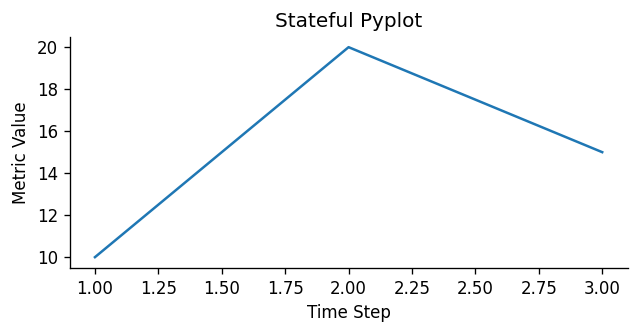

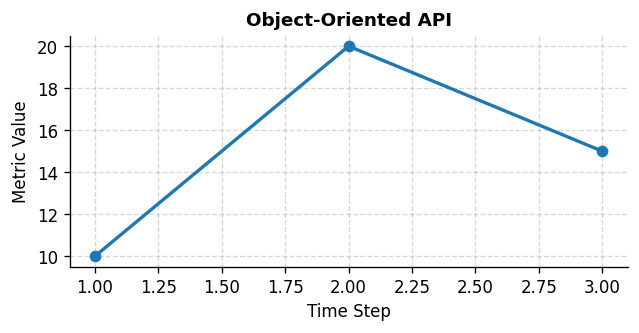

In [2]:
# ==============================================================================
# SECTION 1: MATPLOTLIB ARCHITECTURE
# ==============================================================================

# Simple Pyplot example

plt.figure(figsize=(6, 2.5))

plt.plot(
    [1, 2, 3],
    [10, 20, 15]
)

plt.title("Stateful Pyplot")
plt.xlabel("Time Step")
plt.ylabel("Metric Value")

plt.show()


# Object-Oriented API

fig, ax = plt.subplots(figsize=(6, 2.5))

ax.plot(
    [1, 2, 3],
    [10, 20, 15],
    linewidth=2,
    marker="o"
)

ax.set_title(
    "Object-Oriented API",
    fontsize=11,
    fontweight="bold"
)

ax.set_xlabel("Time Step")
ax.set_ylabel("Metric Value")

ax.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.show()

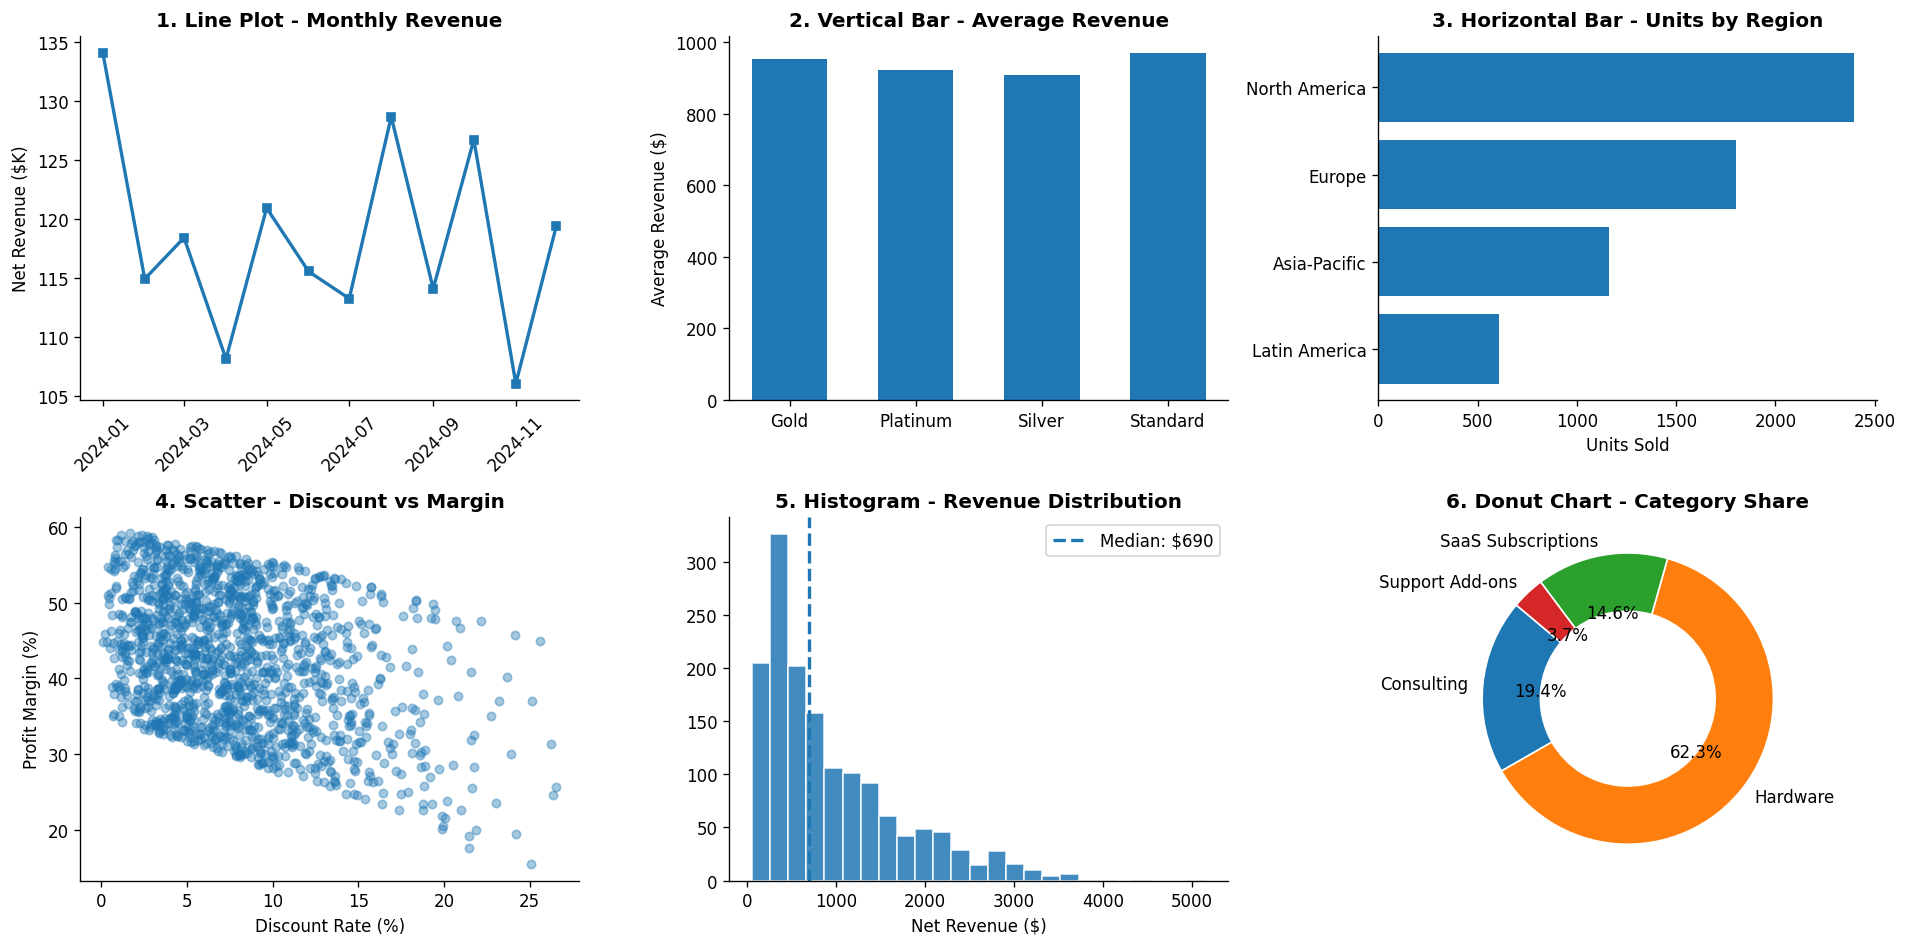

In [3]:
# ==============================================================================
# SECTION 2: CORE MATPLOTLIB PLOT TYPES
# ==============================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8)
)

# 1. Line Plot
monthly_trend = df.groupby("Month")["Net_Revenue"].sum()

axes[0, 0].plot(
    monthly_trend.index,
    monthly_trend.values / 1000,
    linewidth=2,
    marker="s",
    markersize=5
)

axes[0, 0].set_title(
    "1. Line Plot - Monthly Revenue",
    fontweight="bold"
)

axes[0, 0].set_ylabel("Net Revenue ($K)")
axes[0, 0].tick_params(axis="x", rotation=45)


# 2. Vertical Bar Chart
tier_rev = df.groupby("Customer_Tier")["Net_Revenue"].mean()

axes[0, 1].bar(
    tier_rev.index,
    tier_rev.values,
    width=0.6
)

axes[0, 1].set_title(
    "2. Vertical Bar - Average Revenue",
    fontweight="bold"
)

axes[0, 1].set_ylabel("Average Revenue ($)")


# 3. Horizontal Bar Chart
reg_units = df.groupby("Region")["Units_Sold"].sum().sort_values()

axes[0, 2].barh(
    reg_units.index,
    reg_units.values
)

axes[0, 2].set_title(
    "3. Horizontal Bar - Units by Region",
    fontweight="bold"
)

axes[0, 2].set_xlabel("Units Sold")


# 4. Scatter Plot
axes[1, 0].scatter(
    df["Discount_Pct"] * 100,
    df["Profit_Margin_Pct"],
    alpha=0.4,
    s=25
)

axes[1, 0].set_title(
    "4. Scatter - Discount vs Margin",
    fontweight="bold"
)

axes[1, 0].set_xlabel("Discount Rate (%)")
axes[1, 0].set_ylabel("Profit Margin (%)")


# 5. Histogram
axes[1, 1].hist(
    df["Net_Revenue"],
    bins=25,
    edgecolor="white",
    alpha=0.85
)

median_value = df["Net_Revenue"].median()

axes[1, 1].axvline(
    median_value,
    linestyle="--",
    linewidth=2,
    label=f"Median: ${median_value:,.0f}"
)

axes[1, 1].set_title(
    "5. Histogram - Revenue Distribution",
    fontweight="bold"
)

axes[1, 1].set_xlabel("Net Revenue ($)")
axes[1, 1].legend()


# 6. Donut Chart
category_revenue = df.groupby("Category")["Net_Revenue"].sum()

axes[1, 2].pie(
    category_revenue,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(
        width=0.4,
        edgecolor="white"
    )
)

axes[1, 2].set_title(
    "6. Donut Chart - Category Share",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Chart saved successfully!


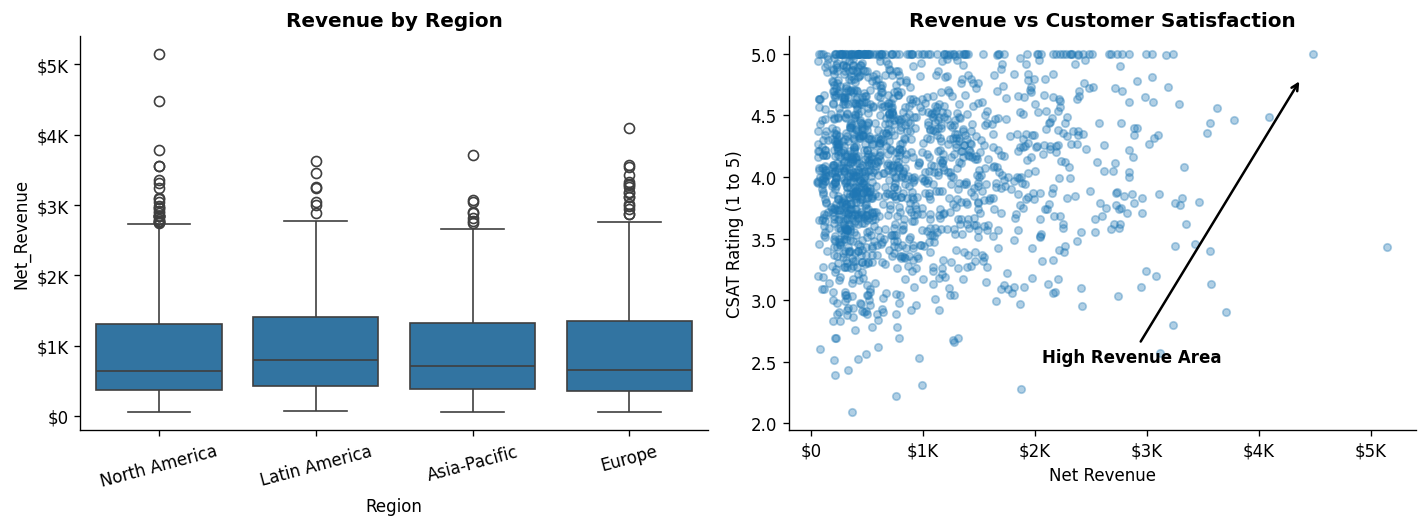

In [4]:
# ==============================================================================
# SECTION 3: SUBPLOTS, TICK FORMATTING & EXPORT
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)


# Currency formatter
def currency_fmt(x, pos):
    if x >= 1000:
        return f"${x/1000:.0f}K"
    else:
        return f"${x:.0f}"


# Boxplot
sns.boxplot(
    data=df,
    x="Region",
    y="Net_Revenue",
    ax=ax1
)

ax1.set_title(
    "Revenue by Region",
    fontweight="bold"
)

ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(currency_fmt)
)

ax1.tick_params(
    axis="x",
    rotation=15
)


# Scatter plot
ax2.scatter(
    df["Net_Revenue"],
    df["CSAT_Score"],
    alpha=0.35,
    s=20
)

ax2.set_title(
    "Revenue vs Customer Satisfaction",
    fontweight="bold"
)

ax2.set_xlabel("Net Revenue")
ax2.set_ylabel("CSAT Rating (1 to 5)")

ax2.xaxis.set_major_formatter(
    ticker.FuncFormatter(currency_fmt)
)


# Annotation
ax2.annotate(
    "High Revenue Area",
    xy=(
        df["Net_Revenue"].max() * 0.85,
        4.8
    ),
    xytext=(
        df["Net_Revenue"].max() * 0.40,
        2.5
    ),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    ),
    fontweight="bold"
)

plt.tight_layout()

fig.savefig(
    "publication_quality_chart.png",
    dpi=300,
    bbox_inches="tight"
)

print("Chart saved successfully!")

plt.show()

In [5]:
# ==============================================================================
# SECTION 4: CHART SELECTION DECISION MATRIX
# ==============================================================================

print("""
CHART SELECTION GUIDE

1. Trend
   Line Chart / Area Chart

2. Distribution
   Histogram / KDE / Boxplot / Violin Plot

3. Comparison
   Bar Chart / Horizontal Bar Chart

4. Relationship
   Scatter Plot / Regression Plot / Heatmap

5. Composition
   Pie Chart / Donut Chart / Stacked Bar Chart
""")


CHART SELECTION GUIDE

1. Trend
   Line Chart / Area Chart

2. Distribution
   Histogram / KDE / Boxplot / Violin Plot

3. Comparison
   Bar Chart / Horizontal Bar Chart

4. Relationship
   Scatter Plot / Regression Plot / Heatmap

5. Composition
   Pie Chart / Donut Chart / Stacked Bar Chart



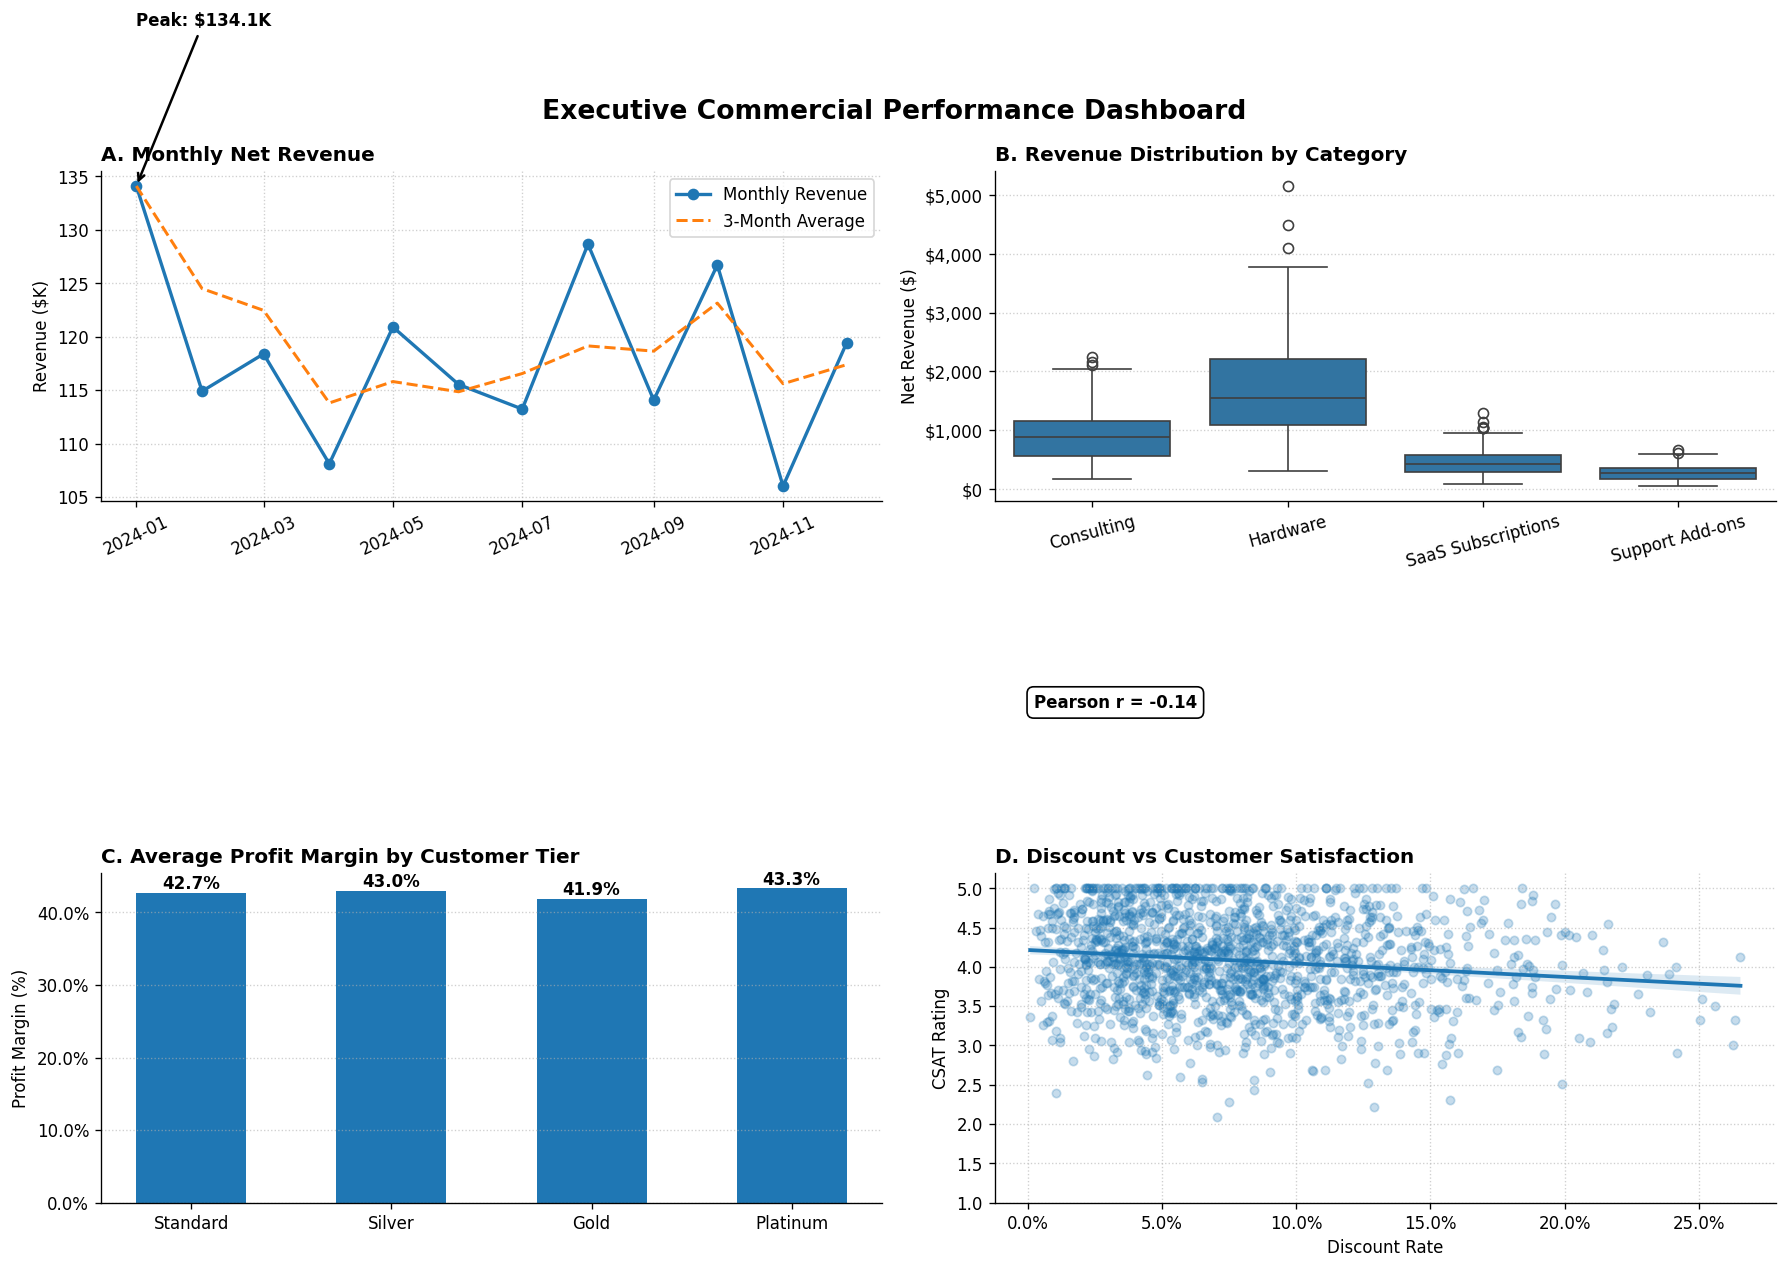

In [6]:
# ==============================================================================
# SECTION 5: 4-PANEL DASHBOARD
# ==============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

fig.suptitle(
    "Executive Commercial Performance Dashboard",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------------------------
# PANEL 1 - TREND
# ------------------------------------------------------------------------------

monthly_summary = (
    df.groupby("Month")["Net_Revenue"]
    .sum()
    .reset_index()
)

monthly_summary["Rolling_3M"] = (
    monthly_summary["Net_Revenue"]
    .rolling(3, min_periods=1)
    .mean()
)

axes[0, 0].plot(
    monthly_summary["Month"],
    monthly_summary["Net_Revenue"] / 1000,
    marker="o",
    linewidth=2,
    label="Monthly Revenue"
)

axes[0, 0].plot(
    monthly_summary["Month"],
    monthly_summary["Rolling_3M"] / 1000,
    linestyle="--",
    linewidth=1.8,
    label="3-Month Average"
)

axes[0, 0].set_title(
    "A. Monthly Net Revenue",
    fontweight="bold",
    loc="left"
)

axes[0, 0].set_ylabel("Revenue ($K)")
axes[0, 0].tick_params(
    axis="x",
    rotation=25
)

axes[0, 0].grid(
    True,
    linestyle=":",
    alpha=0.6
)

axes[0, 0].legend()


# Find peak month
max_rev = monthly_summary["Net_Revenue"].max()

max_date = monthly_summary.loc[
    monthly_summary["Net_Revenue"].idxmax(),
    "Month"
]

axes[0, 0].annotate(
    f"Peak: ${max_rev/1000:.1f}K",
    xy=(
        max_date,
        max_rev / 1000
    ),
    xytext=(
        max_date,
        max_rev / 1000 + 15
    ),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    ),
    fontweight="bold"
)


# ------------------------------------------------------------------------------
# PANEL 2 - DISTRIBUTION
# ------------------------------------------------------------------------------

sns.boxplot(
    data=df,
    x="Category",
    y="Net_Revenue",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "B. Revenue Distribution by Category",
    fontweight="bold",
    loc="left"
)

axes[0, 1].set_ylabel("Net Revenue ($)")
axes[0, 1].set_xlabel("")

axes[0, 1].yaxis.set_major_formatter(
    ticker.StrMethodFormatter("${x:,.0f}")
)

axes[0, 1].tick_params(
    axis="x",
    rotation=15
)

axes[0, 1].grid(
    True,
    axis="y",
    linestyle=":",
    alpha=0.6
)


# ------------------------------------------------------------------------------
# PANEL 3 - COMPARISON
# ------------------------------------------------------------------------------

tier_margin = (
    df.groupby("Customer_Tier")["Profit_Margin_Pct"]
    .mean()
    .reindex([
        "Standard",
        "Silver",
        "Gold",
        "Platinum"
    ])
)

bars = axes[1, 0].bar(
    tier_margin.index,
    tier_margin.values,
    width=0.55
)

axes[1, 0].set_title(
    "C. Average Profit Margin by Customer Tier",
    fontweight="bold",
    loc="left"
)

axes[1, 0].set_ylabel("Profit Margin (%)")

axes[1, 0].yaxis.set_major_formatter(
    ticker.PercentFormatter()
)

axes[1, 0].grid(
    True,
    axis="y",
    linestyle=":",
    alpha=0.6
)


# Add values on bars
for bar in bars:

    height = bar.get_height()

    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


# ------------------------------------------------------------------------------
# PANEL 4 - RELATIONSHIP
# ------------------------------------------------------------------------------

sns.regplot(
    data=df,
    x="Discount_Pct",
    y="CSAT_Score",
    scatter_kws={
        "alpha": 0.25,
        "s": 25
    },
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "D. Discount vs Customer Satisfaction",
    fontweight="bold",
    loc="left"
)

axes[1, 1].set_xlabel("Discount Rate")
axes[1, 1].set_ylabel("CSAT Rating")

axes[1, 1].xaxis.set_major_formatter(
    ticker.PercentFormatter(xmax=1.0)
)

axes[1, 1].set_ylim(
    1.0,
    5.2
)

axes[1, 1].grid(
    True,
    linestyle=":",
    alpha=0.6
)


# Correlation
correlation = np.corrcoef(
    df["Discount_Pct"],
    df["CSAT_Score"]
)[0, 1]

axes[1, 1].text(
    0.05,
    1.5,
    f"Pearson r = {correlation:.2f}",
    transform=axes[1, 1].transAxes,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white"
    ),
    fontweight="bold"
)

plt.tight_layout()

plt.subplots_adjust(
    top=0.92
)

plt.show()

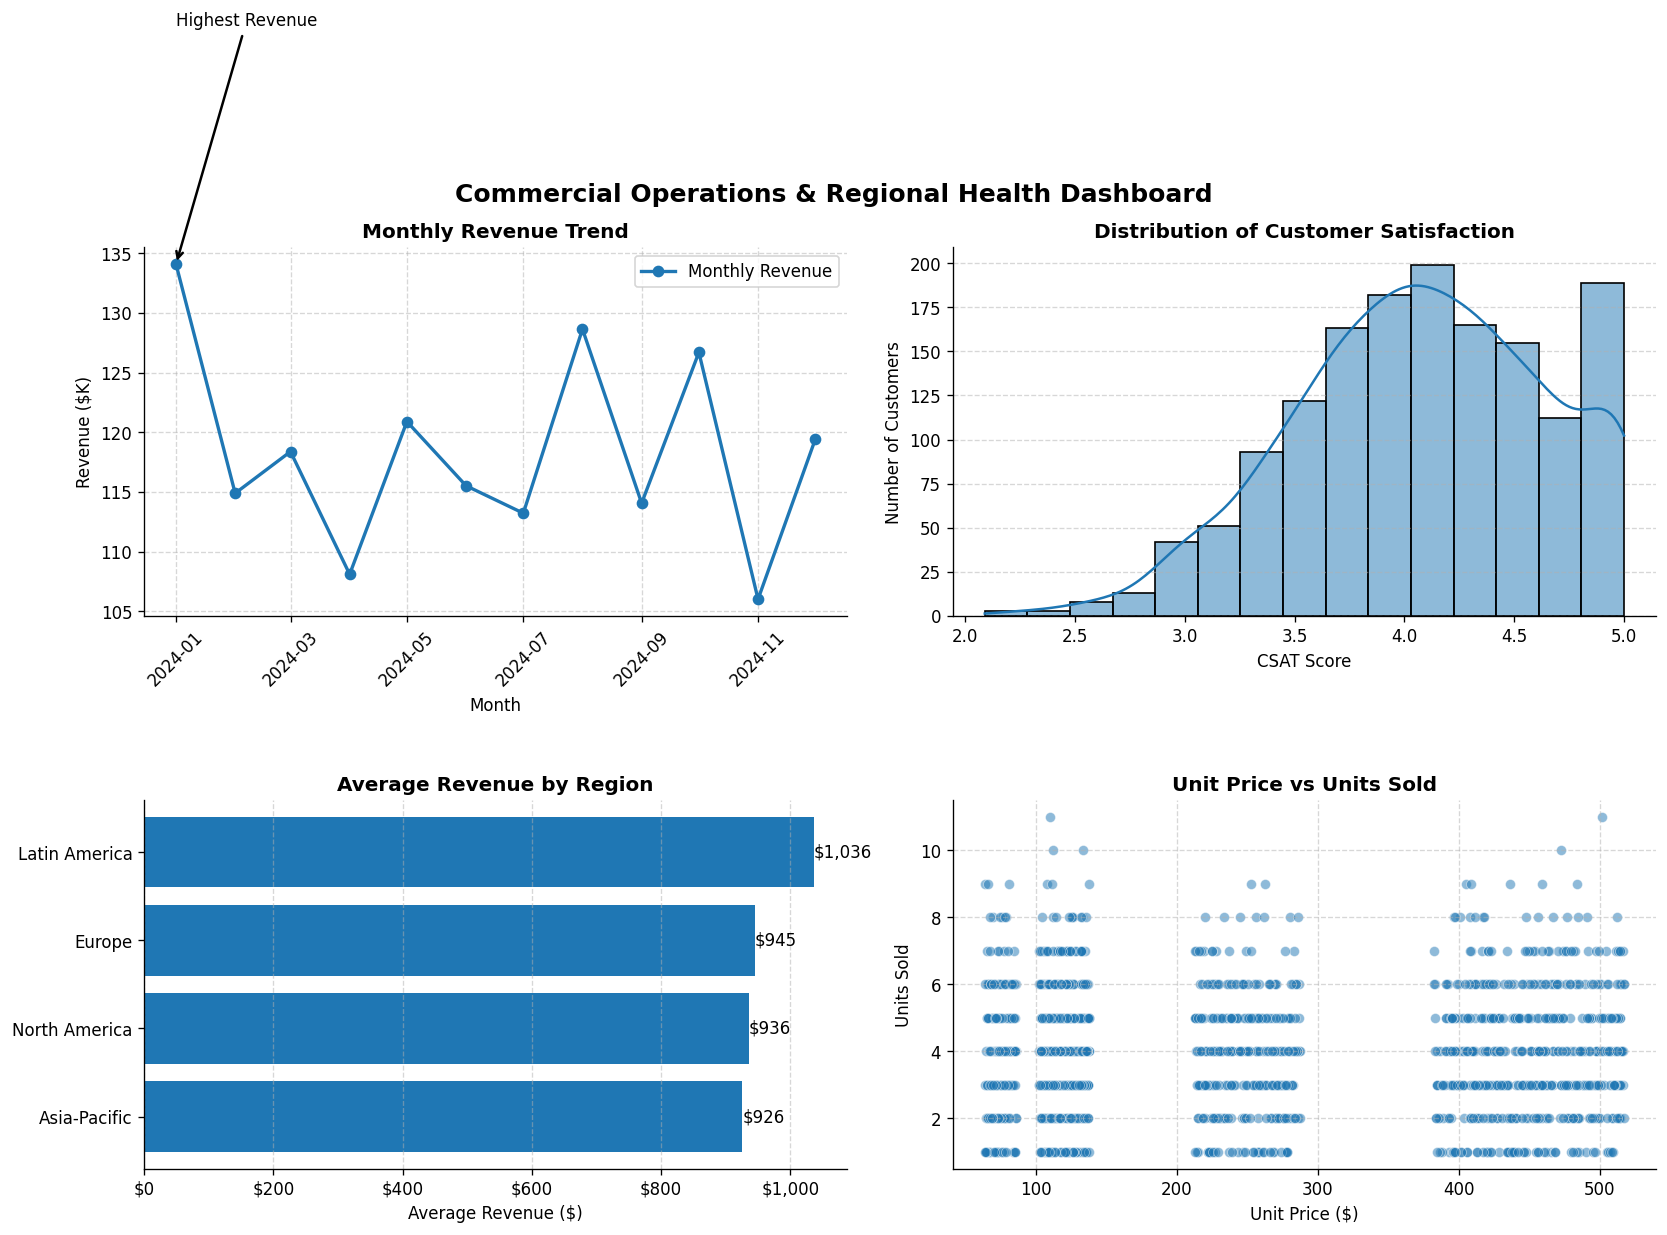

In [7]:
# ==============================================================================
# SECTION 6: STUDENT LAB ASSIGNMENT
# ==============================================================================

# Create 2x2 dashboard
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

fig.suptitle(
    "Commercial Operations & Regional Health Dashboard",
    fontsize=15,
    fontweight="bold"
)


# ------------------------------------------------------------------------------
# PANEL 1: TREND ANALYSIS
# ------------------------------------------------------------------------------

monthly_revenue = (
    df.groupby("Month")["Net_Revenue"]
    .sum()
    .reset_index()
)

axes[0, 0].plot(
    monthly_revenue["Month"],
    monthly_revenue["Net_Revenue"] / 1000,
    marker="o",
    linewidth=2,
    label="Monthly Revenue"
)

axes[0, 0].set_title(
    "Monthly Revenue Trend",
    fontweight="bold"
)

axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue ($K)")

axes[0, 0].tick_params(
    axis="x",
    rotation=45
)

axes[0, 0].grid(
    True,
    linestyle="--",
    alpha=0.5
)

axes[0, 0].legend()


# Annotation for highest month
highest_month = monthly_revenue.loc[
    monthly_revenue["Net_Revenue"].idxmax()
]

axes[0, 0].annotate(
    "Highest Revenue",
    xy=(
        highest_month["Month"],
        highest_month["Net_Revenue"] / 1000
    ),
    xytext=(
        highest_month["Month"],
        highest_month["Net_Revenue"] / 1000 + 20
    ),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    )
)


# ------------------------------------------------------------------------------
# PANEL 2: DISTRIBUTION ANALYSIS
# ------------------------------------------------------------------------------

sns.histplot(
    data=df,
    x="CSAT_Score",
    bins=15,
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Distribution of Customer Satisfaction",
    fontweight="bold"
)

axes[0, 1].set_xlabel("CSAT Score")
axes[0, 1].set_ylabel("Number of Customers")

axes[0, 1].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.5
)


# ------------------------------------------------------------------------------
# PANEL 3: CATEGORICAL COMPARISON
# ------------------------------------------------------------------------------

region_revenue = (
    df.groupby("Region")["Net_Revenue"]
    .mean()
    .sort_values()
)

bars = axes[1, 0].barh(
    region_revenue.index,
    region_revenue.values
)

axes[1, 0].set_title(
    "Average Revenue by Region",
    fontweight="bold"
)

axes[1, 0].set_xlabel("Average Revenue ($)")

axes[1, 0].xaxis.set_major_formatter(
    ticker.StrMethodFormatter("${x:,.0f}")
)

axes[1, 0].grid(
    True,
    axis="x",
    linestyle="--",
    alpha=0.5
)


# Add values to bars
for bar in bars:

    width = bar.get_width()

    axes[1, 0].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center",
        ha="left"
    )


# ------------------------------------------------------------------------------
# PANEL 4: BIVARIATE RELATIONSHIP
# ------------------------------------------------------------------------------

sns.scatterplot(
    data=df,
    x="Unit_Price",
    y="Units_Sold",
    alpha=0.5,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Unit Price vs Units Sold",
    fontweight="bold"
)

axes[1, 1].set_xlabel("Unit Price ($)")
axes[1, 1].set_ylabel("Units Sold")

axes[1, 1].grid(
    True,
    linestyle="--",
    alpha=0.5
)


# Final formatting
plt.tight_layout()

plt.subplots_adjust(
    top=0.92
)

plt.show()

In [8]:
# ==============================================================================
# OPTIONAL: SAVE THE STUDENT DASHBOARD
# ==============================================================================

fig.savefig(
    "student_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

print("Student dashboard saved successfully!")

Student dashboard saved successfully!
